# 04 · Wave Verification — Forecast Hs vs Buoy

**Runnable companion to [`python-verification-guide.md`](../python-verification-guide.md)
(Sea State & Waves) and the [ocean-obs guide](../../observations/ocean-obs-guide.md).**

This notebook verifies a real significant-wave-height (**Hs**) forecast against
real buoy observations, and introduces the **Scatter Index (SI)** — the standard
normalized error metric for waves.

- **Model:** Open-Meteo Marine API (`wave_height`).
- **Obs:** NDBC buoy `51201` (Waimea Bay, Hawaii).

> Live data with committed cached fallback; see [`../../NOTEBOOKS.md`](../../NOTEBOOKS.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from meteo_examples import dataio, verif

BUOY = "51201"
LAT, LON = 21.673, -158.116
START, END = "2026-06-01", "2026-06-08"
plt.rcParams["figure.dpi"] = 110

## 1 · Load forecast and buoy, align on the hour

In [2]:
fc = dataio.open_meteo_marine(LAT, LON, START, END,
                              hourly="wave_height,wave_period").set_index("time")
buoy = dataio.ndbc_realtime(BUOY, prefer_cache=True).set_index("time").sort_index()

obs = buoy["WVHT"].resample("1h").mean().rename("Hs_obs")
mod = fc["wave_height"].rename("Hs_fcst")
m = pd.concat([mod, obs], axis=1).dropna()
print(f"matched hours: {len(m)}")
m.head()

matched hours: 174


/tmp/claude-0/ipykernel_1229947/2815628829.py:7: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  m = pd.concat([mod, obs], axis=1).dropna()


,Hs_fcst,Hs_obs
time,,
2026-06-01 00:00:00,1.40,1.10
2026-06-01 01:00:00,1.40,1.20
2026-06-01 02:00:00,1.38,1.25
2026-06-01 03:00:00,1.38,1.20
2026-06-01 04:00:00,1.40,1.15


## 2 · Metrics, including the Scatter Index

`SI = unbiased-RMSE / mean(obs)` removes the mean bias before normalizing, so it
isolates the *random* error as a fraction of the typical wave height.
Rule of thumb: **<10% excellent, 10–15% good, >20% investigate.**

In [3]:
stats = verif.continuous_metrics(m["Hs_fcst"], m["Hs_obs"])
si = verif.scatter_index(m["Hs_fcst"], m["Hs_obs"])
print(f"ME (bias) = {stats['ME']:+.2f} m")
print(f"RMSE      = {stats['RMSE']:.2f} m")
print(f"r         = {stats['r']:.3f}")
print(f"Scatter Index = {si*100:.1f} %")

ME (bias) = +0.19 m
RMSE      = 0.25 m
r         = 0.690
Scatter Index = 11.4 %


## 3 · Time series

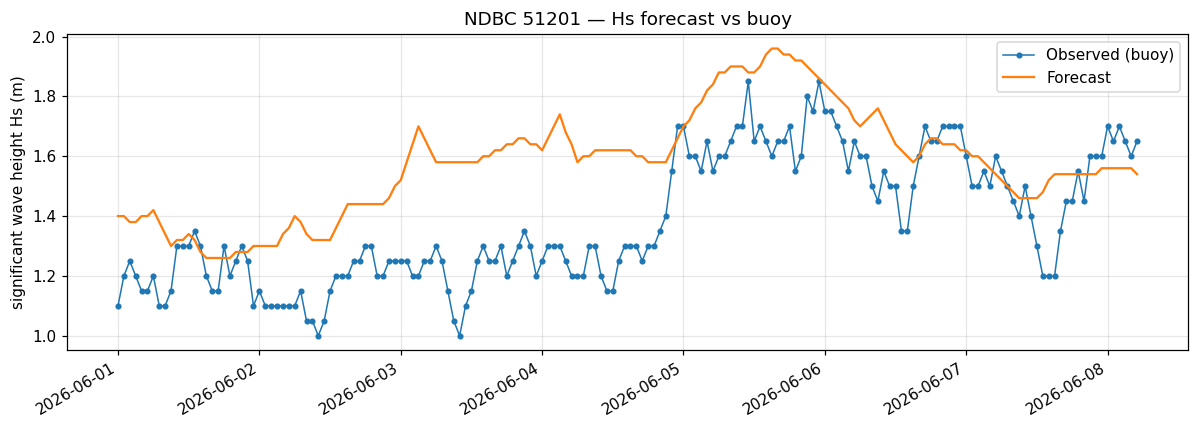

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(m.index, m["Hs_obs"], "o-", ms=3, lw=1, label="Observed (buoy)")
ax.plot(m.index, m["Hs_fcst"], "-", lw=1.5, label="Forecast")
ax.set(ylabel="significant wave height Hs (m)",
       title=f"NDBC {BUOY} — Hs forecast vs buoy")
ax.legend(); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.tight_layout()

## 4 · Scatter and Q–Q

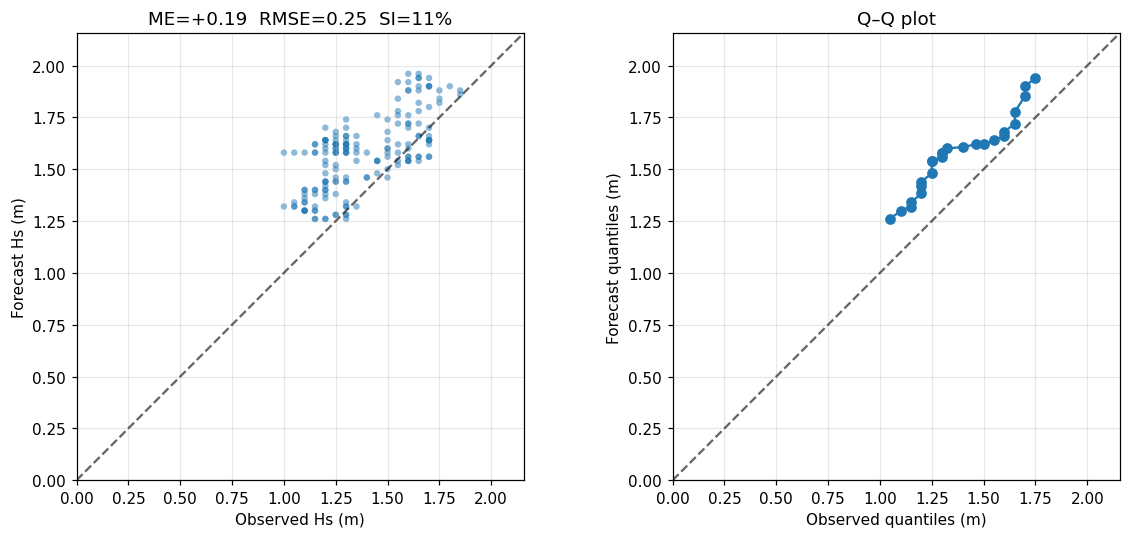

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5))
lims = [0, max(m.max().max(), 1) * 1.1]
a1.scatter(m["Hs_obs"], m["Hs_fcst"], s=18, alpha=0.5, edgecolors="none")
a1.plot(lims, lims, "k--", alpha=0.6)
a1.set(xlim=lims, ylim=lims, xlabel="Observed Hs (m)", ylabel="Forecast Hs (m)",
       title=f"ME={stats['ME']:+.2f}  RMSE={stats['RMSE']:.2f}  SI={si*100:.0f}%")
a1.set_aspect("equal"); a1.grid(alpha=0.3)

q = np.linspace(2, 98, 25)
a2.plot(np.percentile(m["Hs_obs"], q), np.percentile(m["Hs_fcst"], q), "o-")
a2.plot(lims, lims, "k--", alpha=0.6)
a2.set(xlim=lims, ylim=lims, xlabel="Observed quantiles (m)",
       ylabel="Forecast quantiles (m)", title="Q–Q plot")
a2.set_aspect("equal"); a2.grid(alpha=0.3)
plt.tight_layout()

---
### Notes & next steps
- The same workflow verifies model output from
  [WW3](../../models/notebooks/ww3_propagation.ipynb) or
  [SWAN](../../models/notebooks/swan_idealized_fetch.ipynb): extract `Hs` at the
  buoy location and reuse `verif.continuous_metrics` + `verif.scatter_index`.
- Add wave **period** and **direction** (circular — use `verif.wind_direction_mae`)
  for a complete sea-state verification.
- Swap `BUOY`/`LAT`/`LON` for a station near your domain (NDBC station list:
  https://www.ndbc.noaa.gov/).